In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import seaborn as sns

from dynamax.hidden_markov_model import LinearAutoregressiveHMM

import pandas as pd
import numpy as np


import lissa as li

In [2]:
totalData = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)
totalData.rename(columns={"index":"time"},inplace=True)
totalData.drop(columns=["Unnamed: 0"],inplace=True)

Headers = [
    #'ESP discharge temperature sensor',
    'ESP intake temperature',
    'ESP motor temperature',
    'Well head Temperature',
    'ESP intake Pressure',
    'ESP discharge pressure',
    #'ESP differential pressure',
    'Well head pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'Current Mean',
    'ESP Vibration X',
    'ESP Vibration Y',
    #'ESP Power',
    #"Well_down"
    ]

/tmp/ipykernel_364834/1698806942.py:1: DtypeWarning: Columns (18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  totalData = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)


In [3]:
totalData["Radius"] = totalData[Headers].pow(2).sum(axis=1).pow(1/2)

In [4]:
mainSeed = 971215
np.random.seed(mainSeed)

PCAHeaders = [str(i) for i in range(0,7)]

pumpList = totalData["Well Run"].unique()

X_train, trainLength, X_test, testLength, modelData, totalLength = li.Splitter(pumpList=pumpList,proportion=0.75,entireData=totalData)

In [5]:
X_train_jnp = jnp.array(X_train["Radius"]).reshape(-1,1)
trainLength_jnp = jnp.array(trainLength)
X_test_jnp = jnp.array(X_test["Radius"]).reshape(-1,1)
testLength_jnp = jnp.array(testLength)
modelData_jnp = jnp.array(modelData["Radius"]).reshape(-1,1)
totalLength_jnp = jnp.array(totalLength)


In [14]:
# Now fit an HMM to the emissions
key1, key2 = jr.split(jr.PRNGKey(0), 2)
num_states = 2
num_lags = 8

emissions = X_train_jnp

# Initialize with K-Means
arhmm = LinearAutoregressiveHMM(num_states, 1, num_lags=num_lags)
params, props = arhmm.initialize(key=jr.PRNGKey(1), method="prior", emissions=emissions)

inputsAR = arhmm.compute_inputs(X_train_jnp)

# # Fit with EM
fitted_params, lps = arhmm.fit_em(params, props, emissions=X_train_jnp,inputs=inputsAR,num_iters=20)

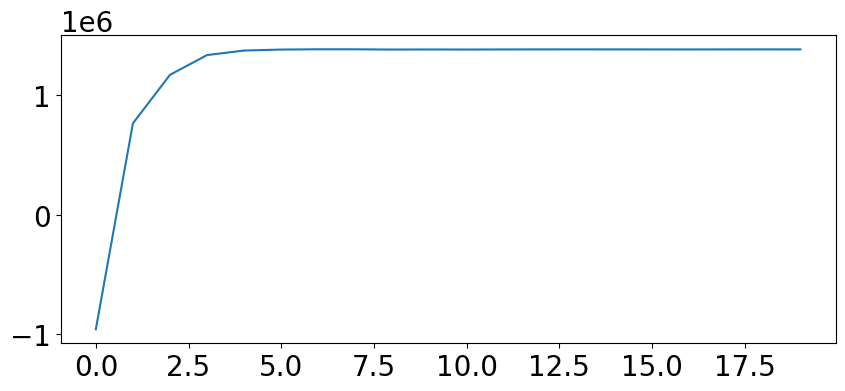

In [15]:
plt.figure(figsize=(10,4))
plt.plot(lps)

In [16]:
pumpData = jnp.array(totalData.loc[totalData["Well Run"]==pumpList[0]]["Radius"].to_numpy()).reshape(-1,1)
inputsAR_pump = arhmm.compute_inputs(pumpData)


posterior = arhmm.smoother(fitted_params, pumpData, inputs=inputsAR_pump)
states = arhmm.most_likely_states(fitted_params, pumpData, inputs=inputsAR_pump)

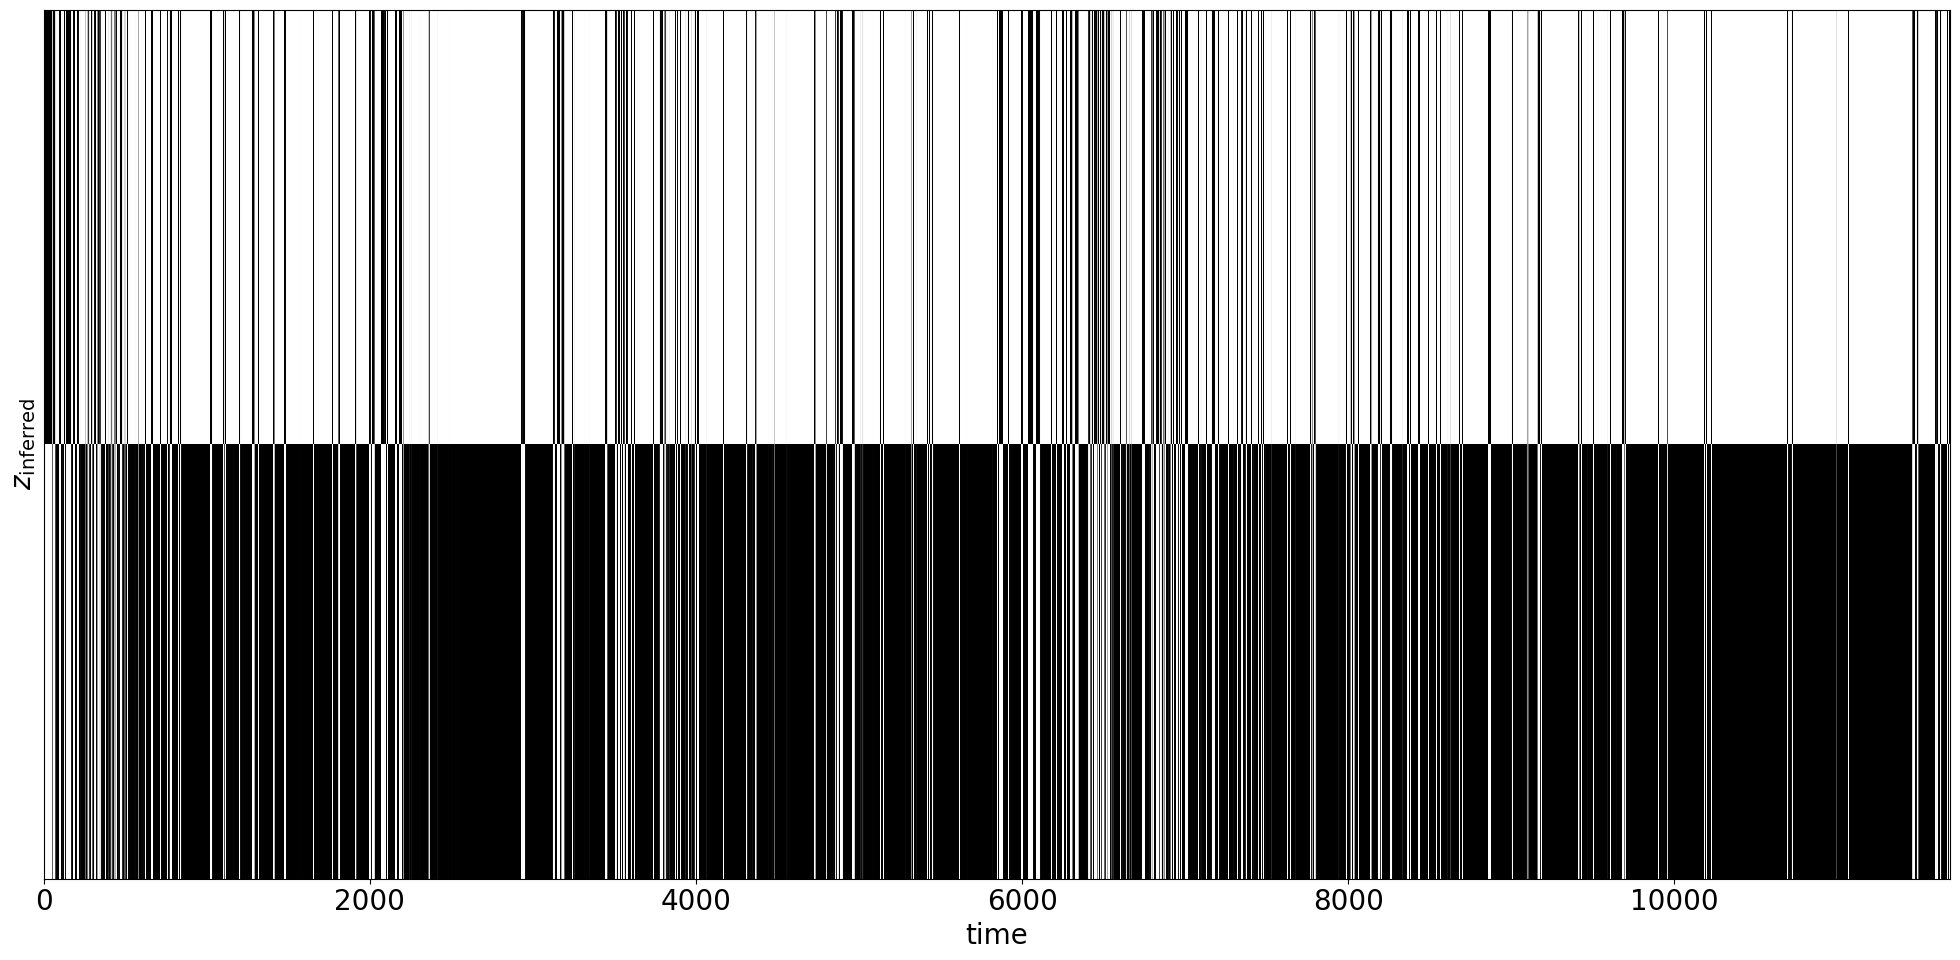

In [17]:
plt.figure(figsize=(20,10))
plt.imshow(posterior.smoothed_probs.T, aspect="auto", interpolation="none", cmap="Greys", vmin=0, vmax=1)

plt.ylabel("$z_{\\mathrm{inferred}}$")
plt.yticks([])
plt.xlabel("time")

plt.tight_layout()

In [18]:
inputsAR_model = arhmm.compute_inputs(modelData_jnp)

states = arhmm.most_likely_states(fitted_params, modelData_jnp, inputs=inputsAR_model)

In [19]:
totalData["Full States"] = 0
totalData.loc[modelData["Radius"].index,"Full States"] = states+1

In [20]:
vibeHeader = ["ESP Vibration X","ESP Vibration Y"]
esotericHeader = ['Water Cut @ 20degC - 1 atm', 'Choke Opening']

n = [2]

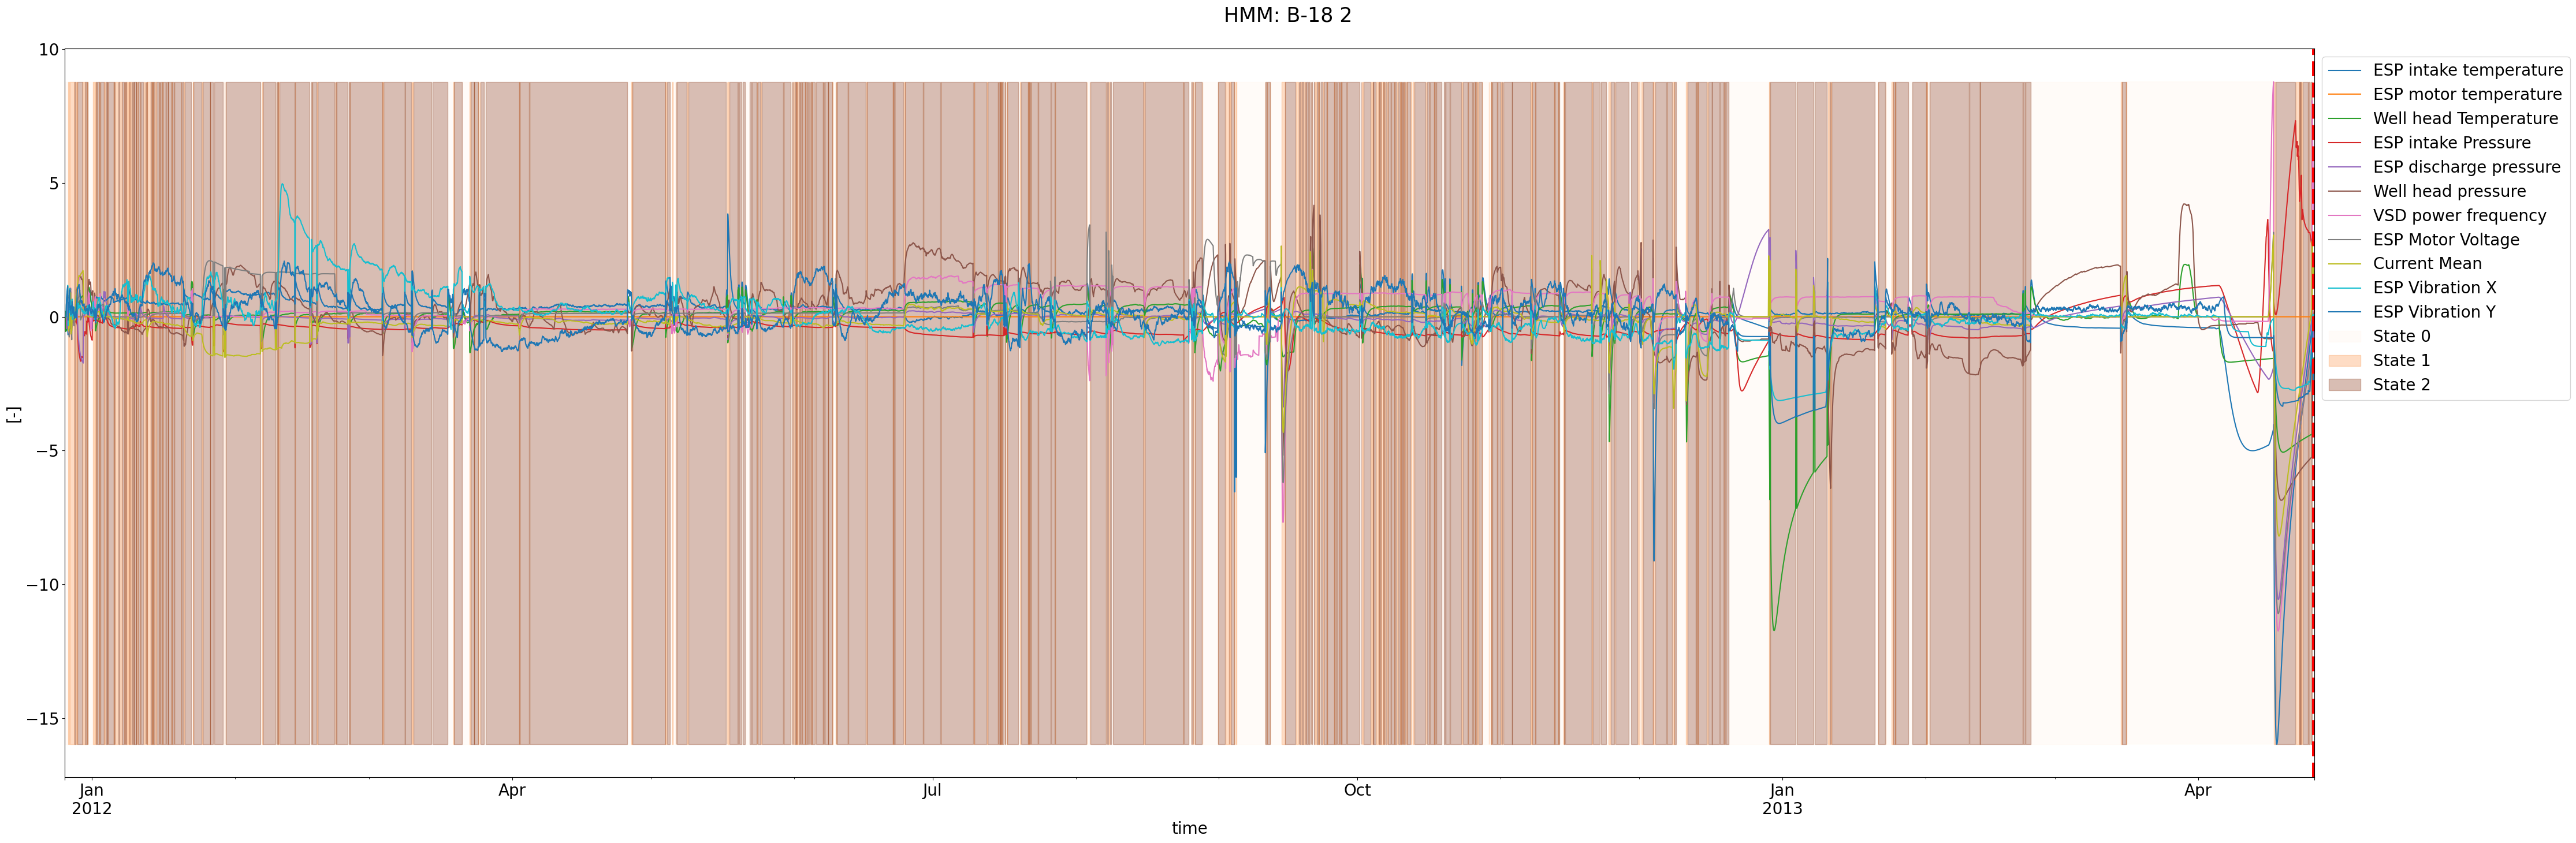

In [21]:
pump = pumpList[0]
pumpData = totalData.loc[totalData["Well Run"]==pump].copy()
fig,axs = li.HMMPicture(pumpData,pump,props=[Headers],measures='[-]',states=["Full States"], numberOfStates=n, figsize=(45,15))
plt.rcParams["font.size"]=20

#fig.savefig("../imagens_gerais/pumps/"+pump+"markovrun.jpg")
